In [ ]:
!nvidia-smi 

Sun Mar 29 23:06:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [3]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.8/112.6 GB disk)


## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jmvAOZ6rkkCH3k0AkuqP")
project = rf.workspace("major-project-1-pw7i8").project("combined-dataset-yjbpr")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to combined-dataset-1 in yolov11:: 100%|██████████| 11136/11136 [00:01<00:00, 7073.70it/s]


## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

/content
100% 18.4M/18.4M [00:00<00:00, 107MB/s] 
New https://pypi.org/project/ultralytics/8.4.14 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/CombinedData-1/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None,

### 20 epochs


In [5]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=20 imgsz=640 plots=True

/content
100% 18.4M/18.4M [00:00<00:00, 157MB/s]
New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/combined-dataset-1/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=N

###30 epochs

In [14]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=30 imgsz=640 plots=True

/content
New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/combined-dataset-1/data.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, sh

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [7]:
!ls {HOME}/runs/detect/train/

args.yaml					     train_batch1.jpg
confusion_matrix_normalized.png			     train_batch2.jpg
confusion_matrix.png				     train_batch3320.jpg
events.out.tfevents.1774825673.26b833cee1fb.10304.0  train_batch3321.jpg
F1_curve.png					     train_batch3322.jpg
labels_correlogram.jpg				     val_batch0_labels.jpg
labels.jpg					     val_batch0_pred.jpg
P_curve.png					     val_batch1_labels.jpg
PR_curve.png					     val_batch1_pred.jpg
R_curve.png					     val_batch2_labels.jpg
results.csv					     val_batch2_pred.jpg
results.png					     weights
train_batch0.jpg


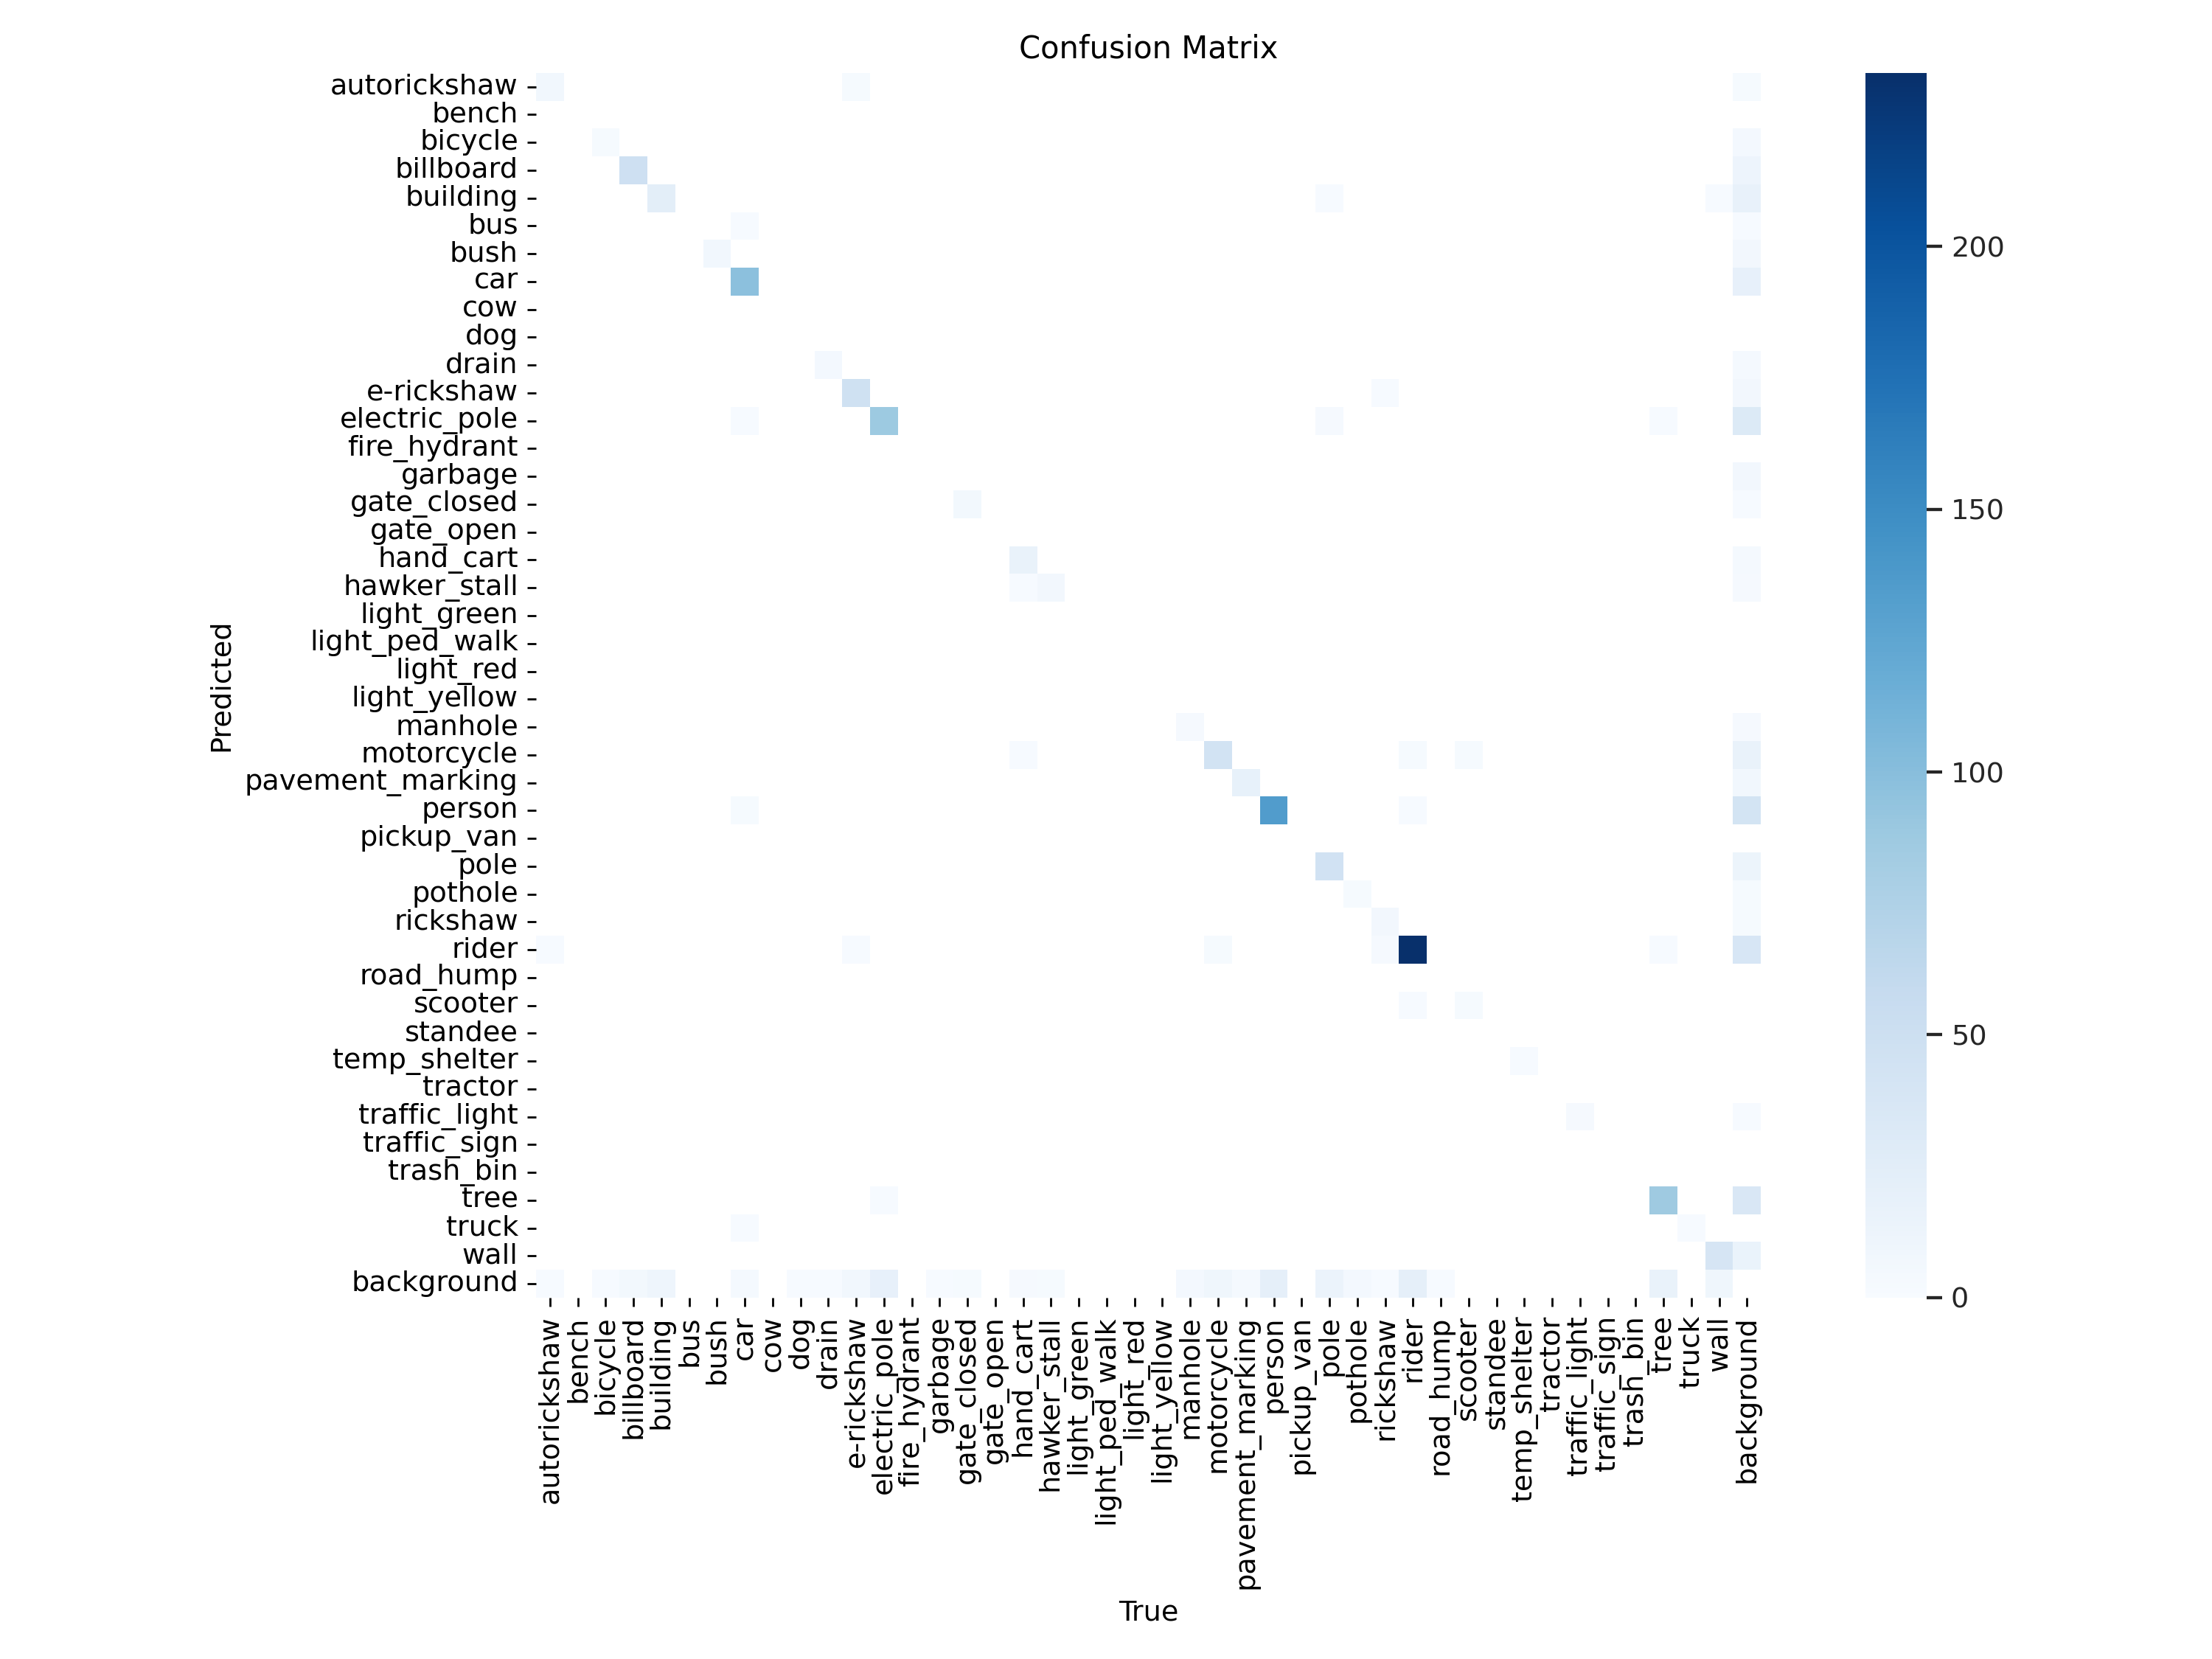

In [8]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train2/confusion_matrix.png', width=600)

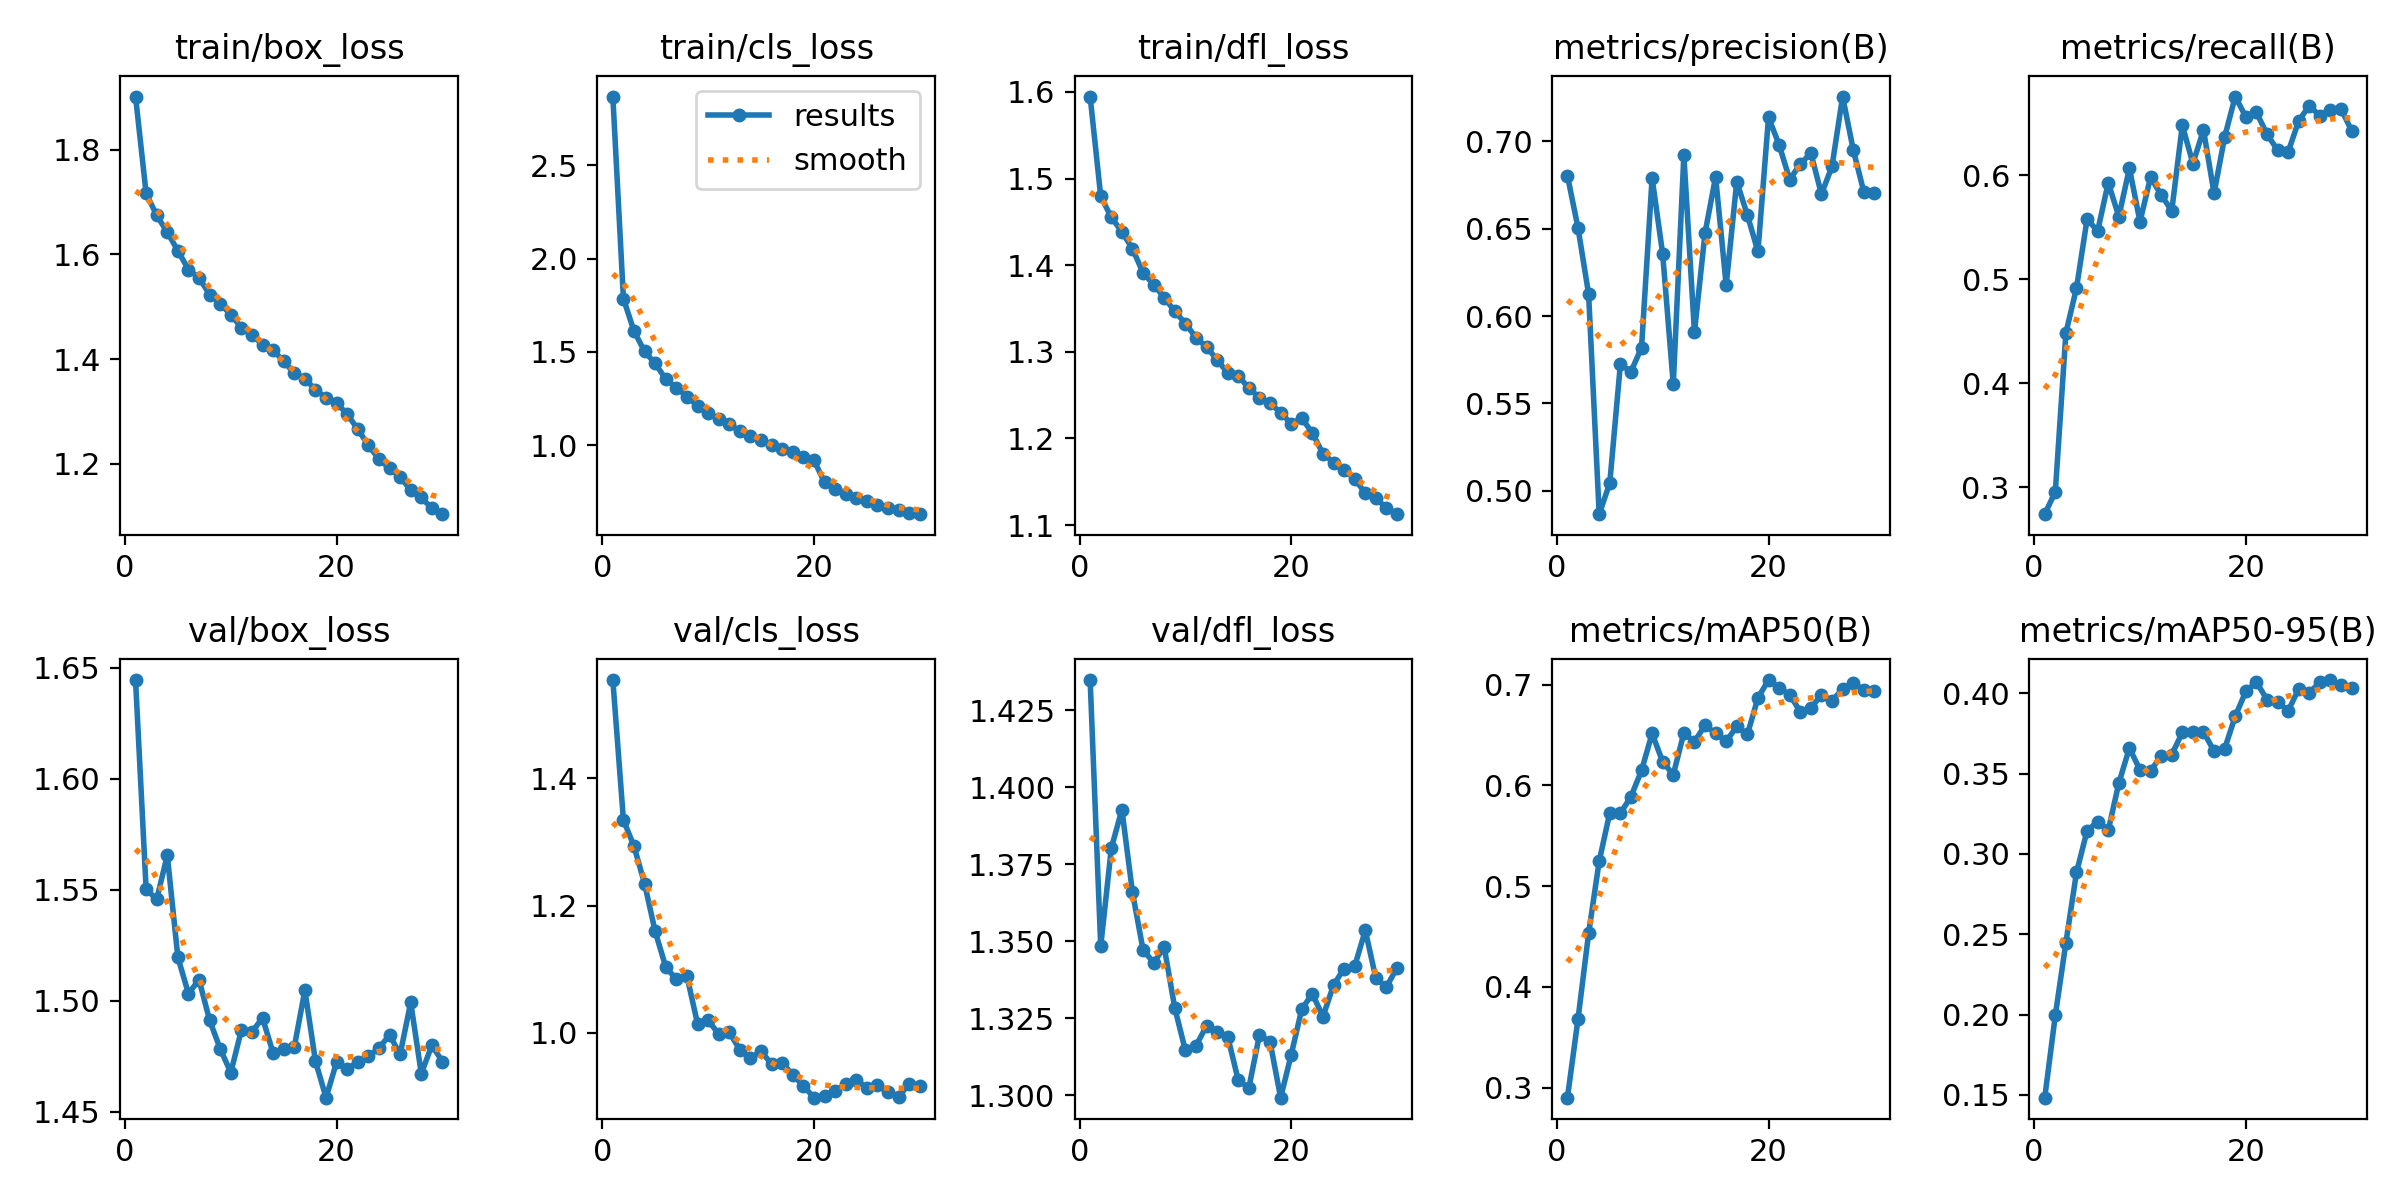

In [9]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train2/results.png', width=600)

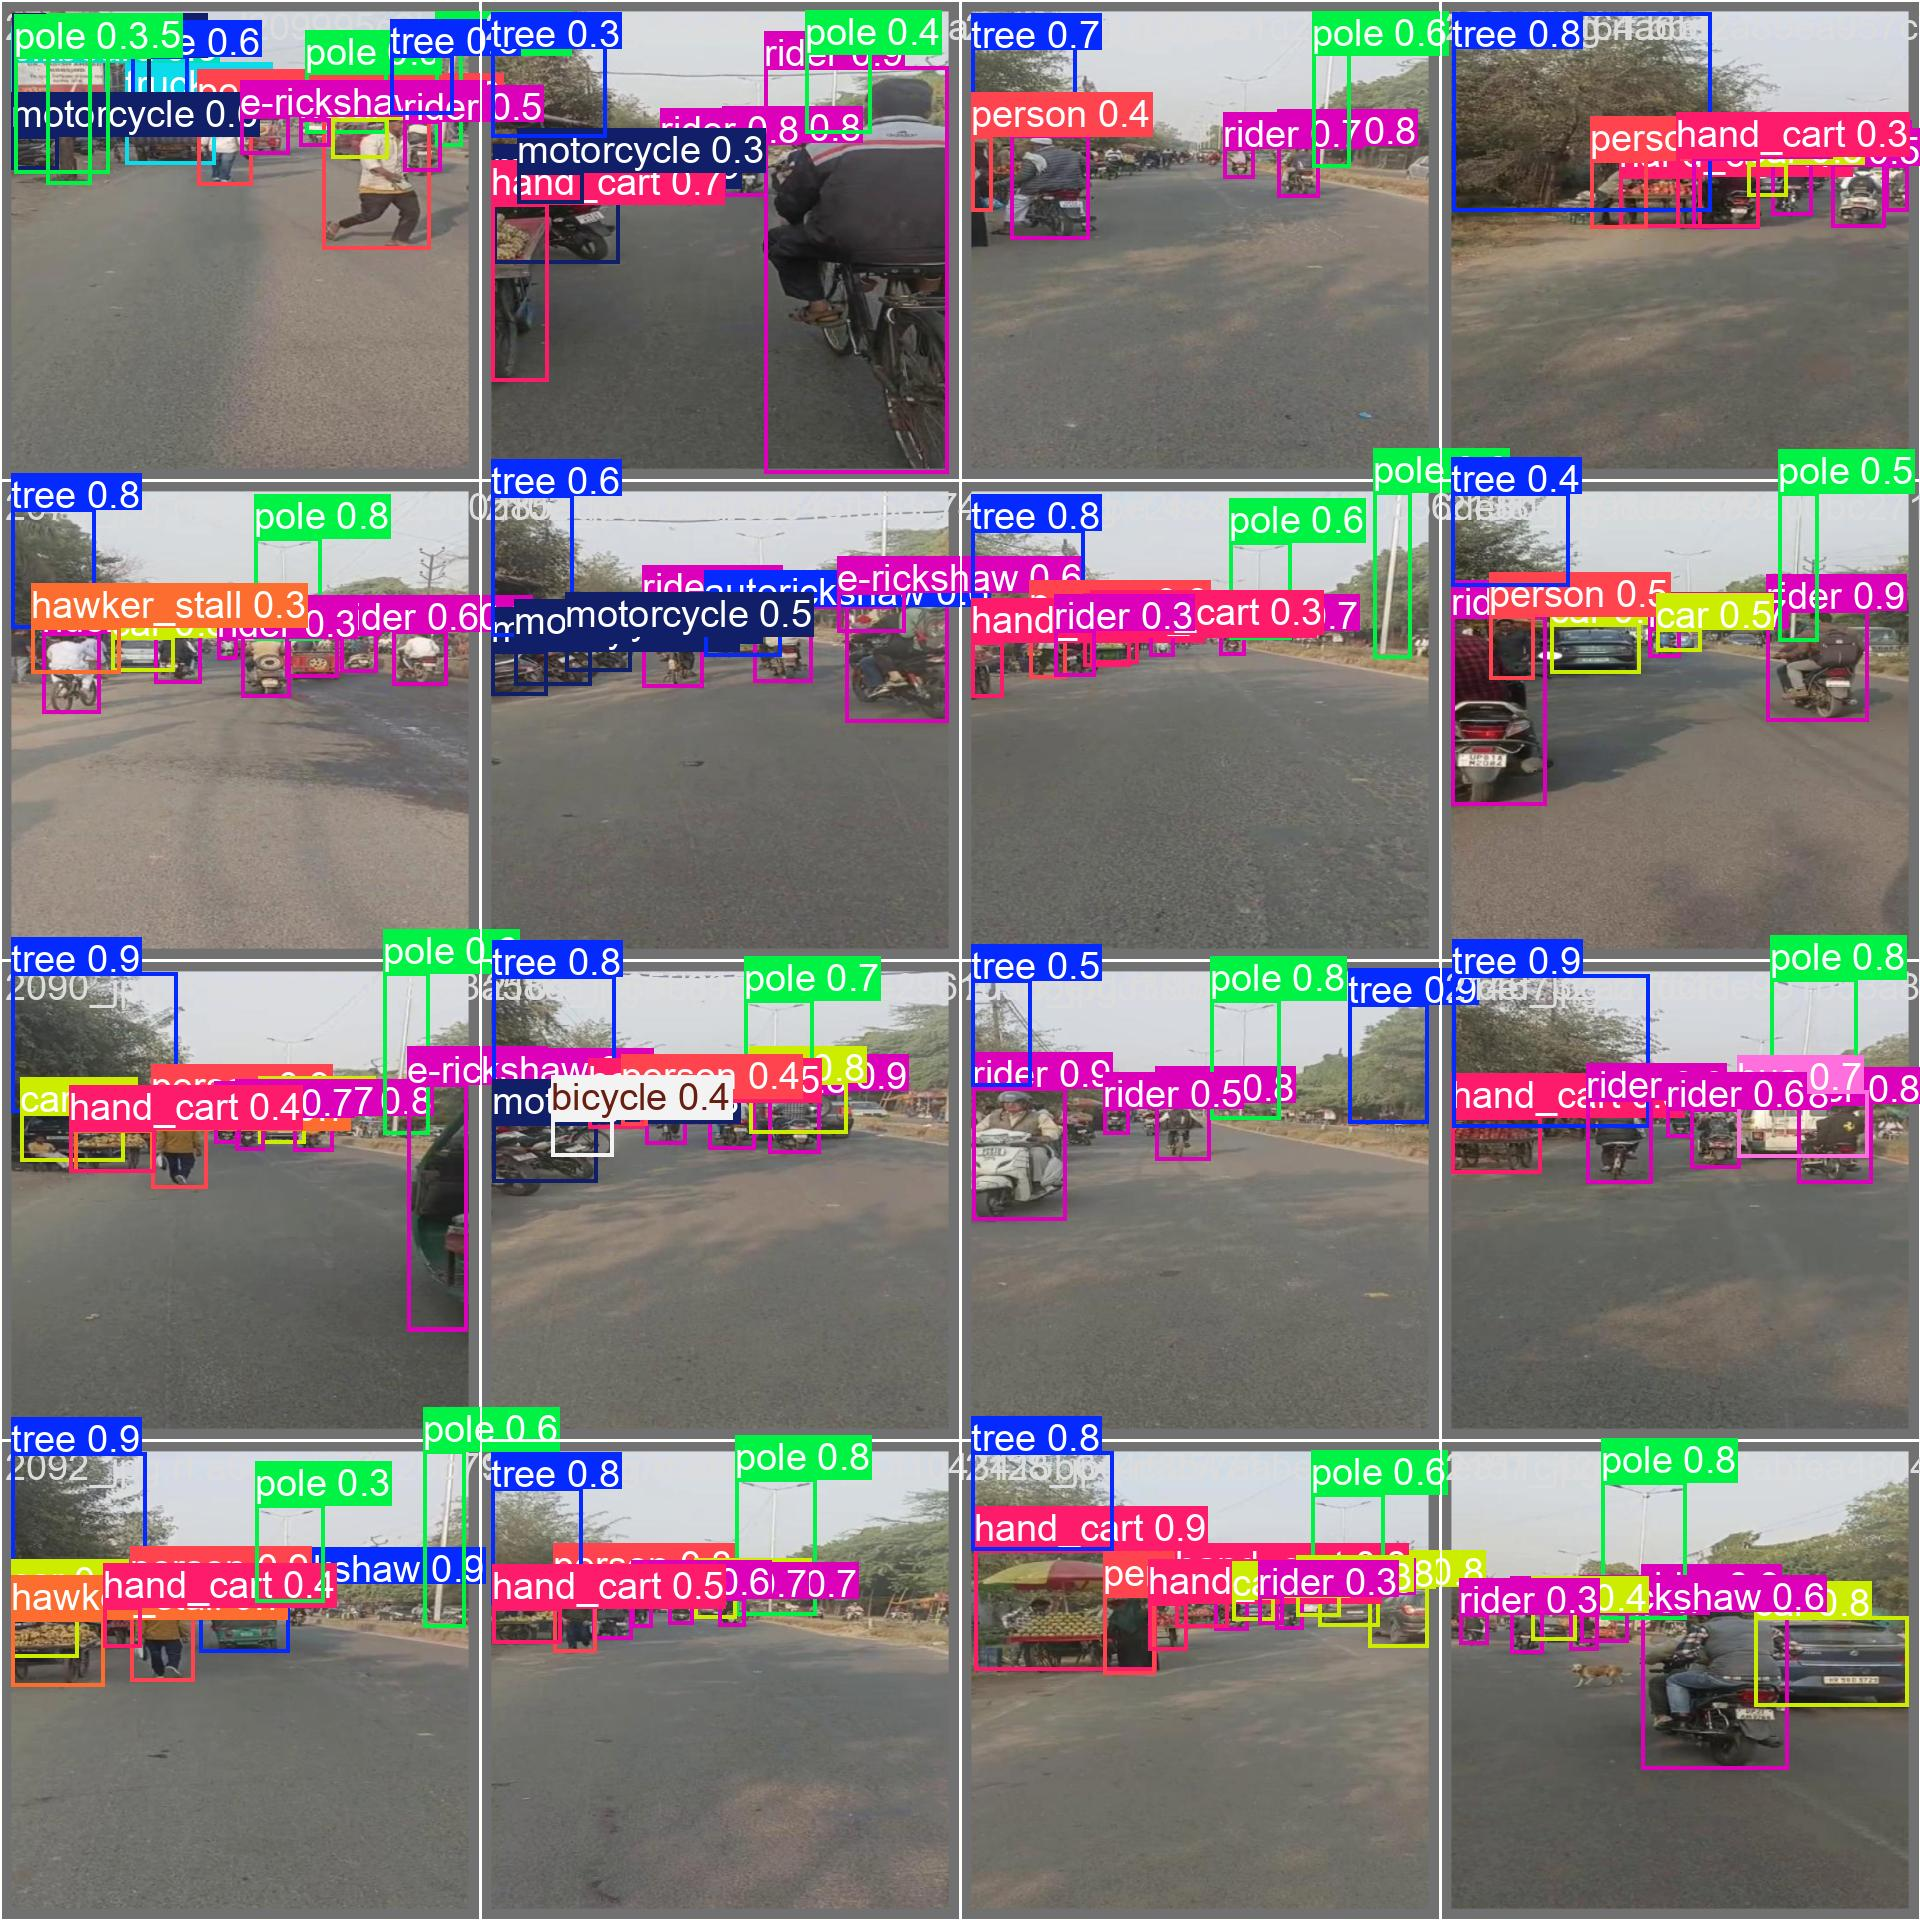

In [10]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train2/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [11]:
!yolo task=detect mode=val model={HOME}/runs/detect/train2/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,429,441 parameters, 0 gradients, 21.4 GFLOPs
val: Scanning /content/combined-dataset-1/valid/labels.cache... 167 images, 0 backgrounds, 0 corrupt: 100% 167/167 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 11/11 [00:04<00:00,  2.66it/s]
                   all        167       1183      0.694      0.663      0.702      0.409
          autorickshaw         10         10       0.75        0.8      0.757      0.451
               bicycle          3          3      0.341      0.667      0.698       0.42
             billboard         38         55      0.852      0.839      0.923      0.643
              building         30         35      0.536      0.543      0.497      0.251
                  bush          8          8      0.638      0.875      0.893      0.614
                   car         81        

## Inference with custom model

In [12]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train2/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,429,441 parameters, 0 gradients, 21.4 GFLOPs

image 1/91 /content/combined-dataset-1/test/images/2058_jpg.rf.42f9d288de6c1ca909c5f30a97a43cdb.jpg: 640x640 2 persons, 2 poles, 4 riders, 1 tree, 1 truck, 15.6ms
image 2/91 /content/combined-dataset-1/test/images/2073_jpg.rf.4feb42e1f95f76524316e3815f86780b.jpg: 640x640 1 car, 1 e-rickshaw, 1 hawker_stall, 1 person, 1 pole, 3 riders, 1 tree, 15.7ms
image 3/91 /content/combined-dataset-1/test/images/2078_jpg.rf.ffe46e88ddcd28c3d25da0a3b9b085fd.jpg: 640x640 1 car, 1 person, 2 poles, 3 riders, 1 tree, 15.6ms
image 4/91 /content/combined-dataset-1/test/images/2079_jpg.rf.52187ee2ef71e3db35937717d377b70a.jpg: 640x640 2 motorcycles, 4 persons, 1 pole, 3 riders, 1 tree, 15.6ms
image 5/91 /content/combined-dataset-1/test/images/2082_jpg.rf.f73f96909441b9ebcb47f5761b59fd13.jpg: 640x640 1 e-rickshaw, 3 motorcycles, 1 person, 1 po

**NOTE:** Let's take a look at few results.

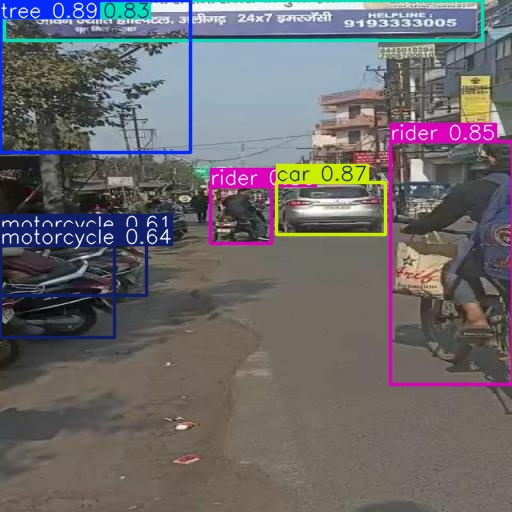

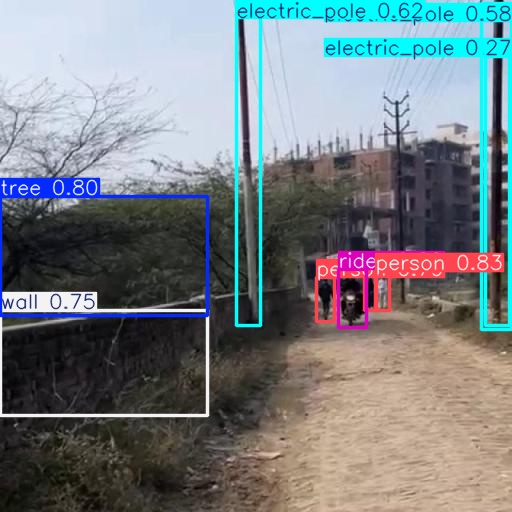

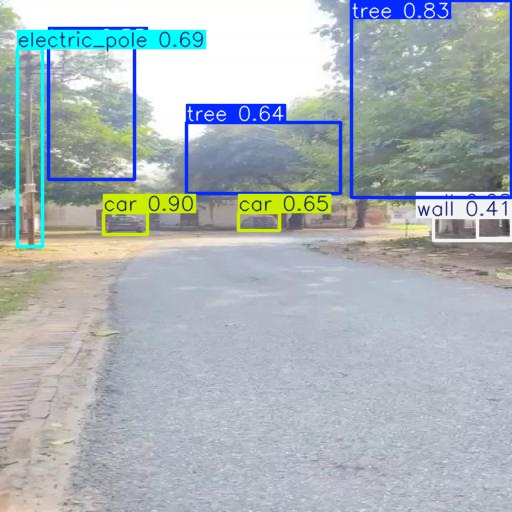

In [13]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

###30 epoch results


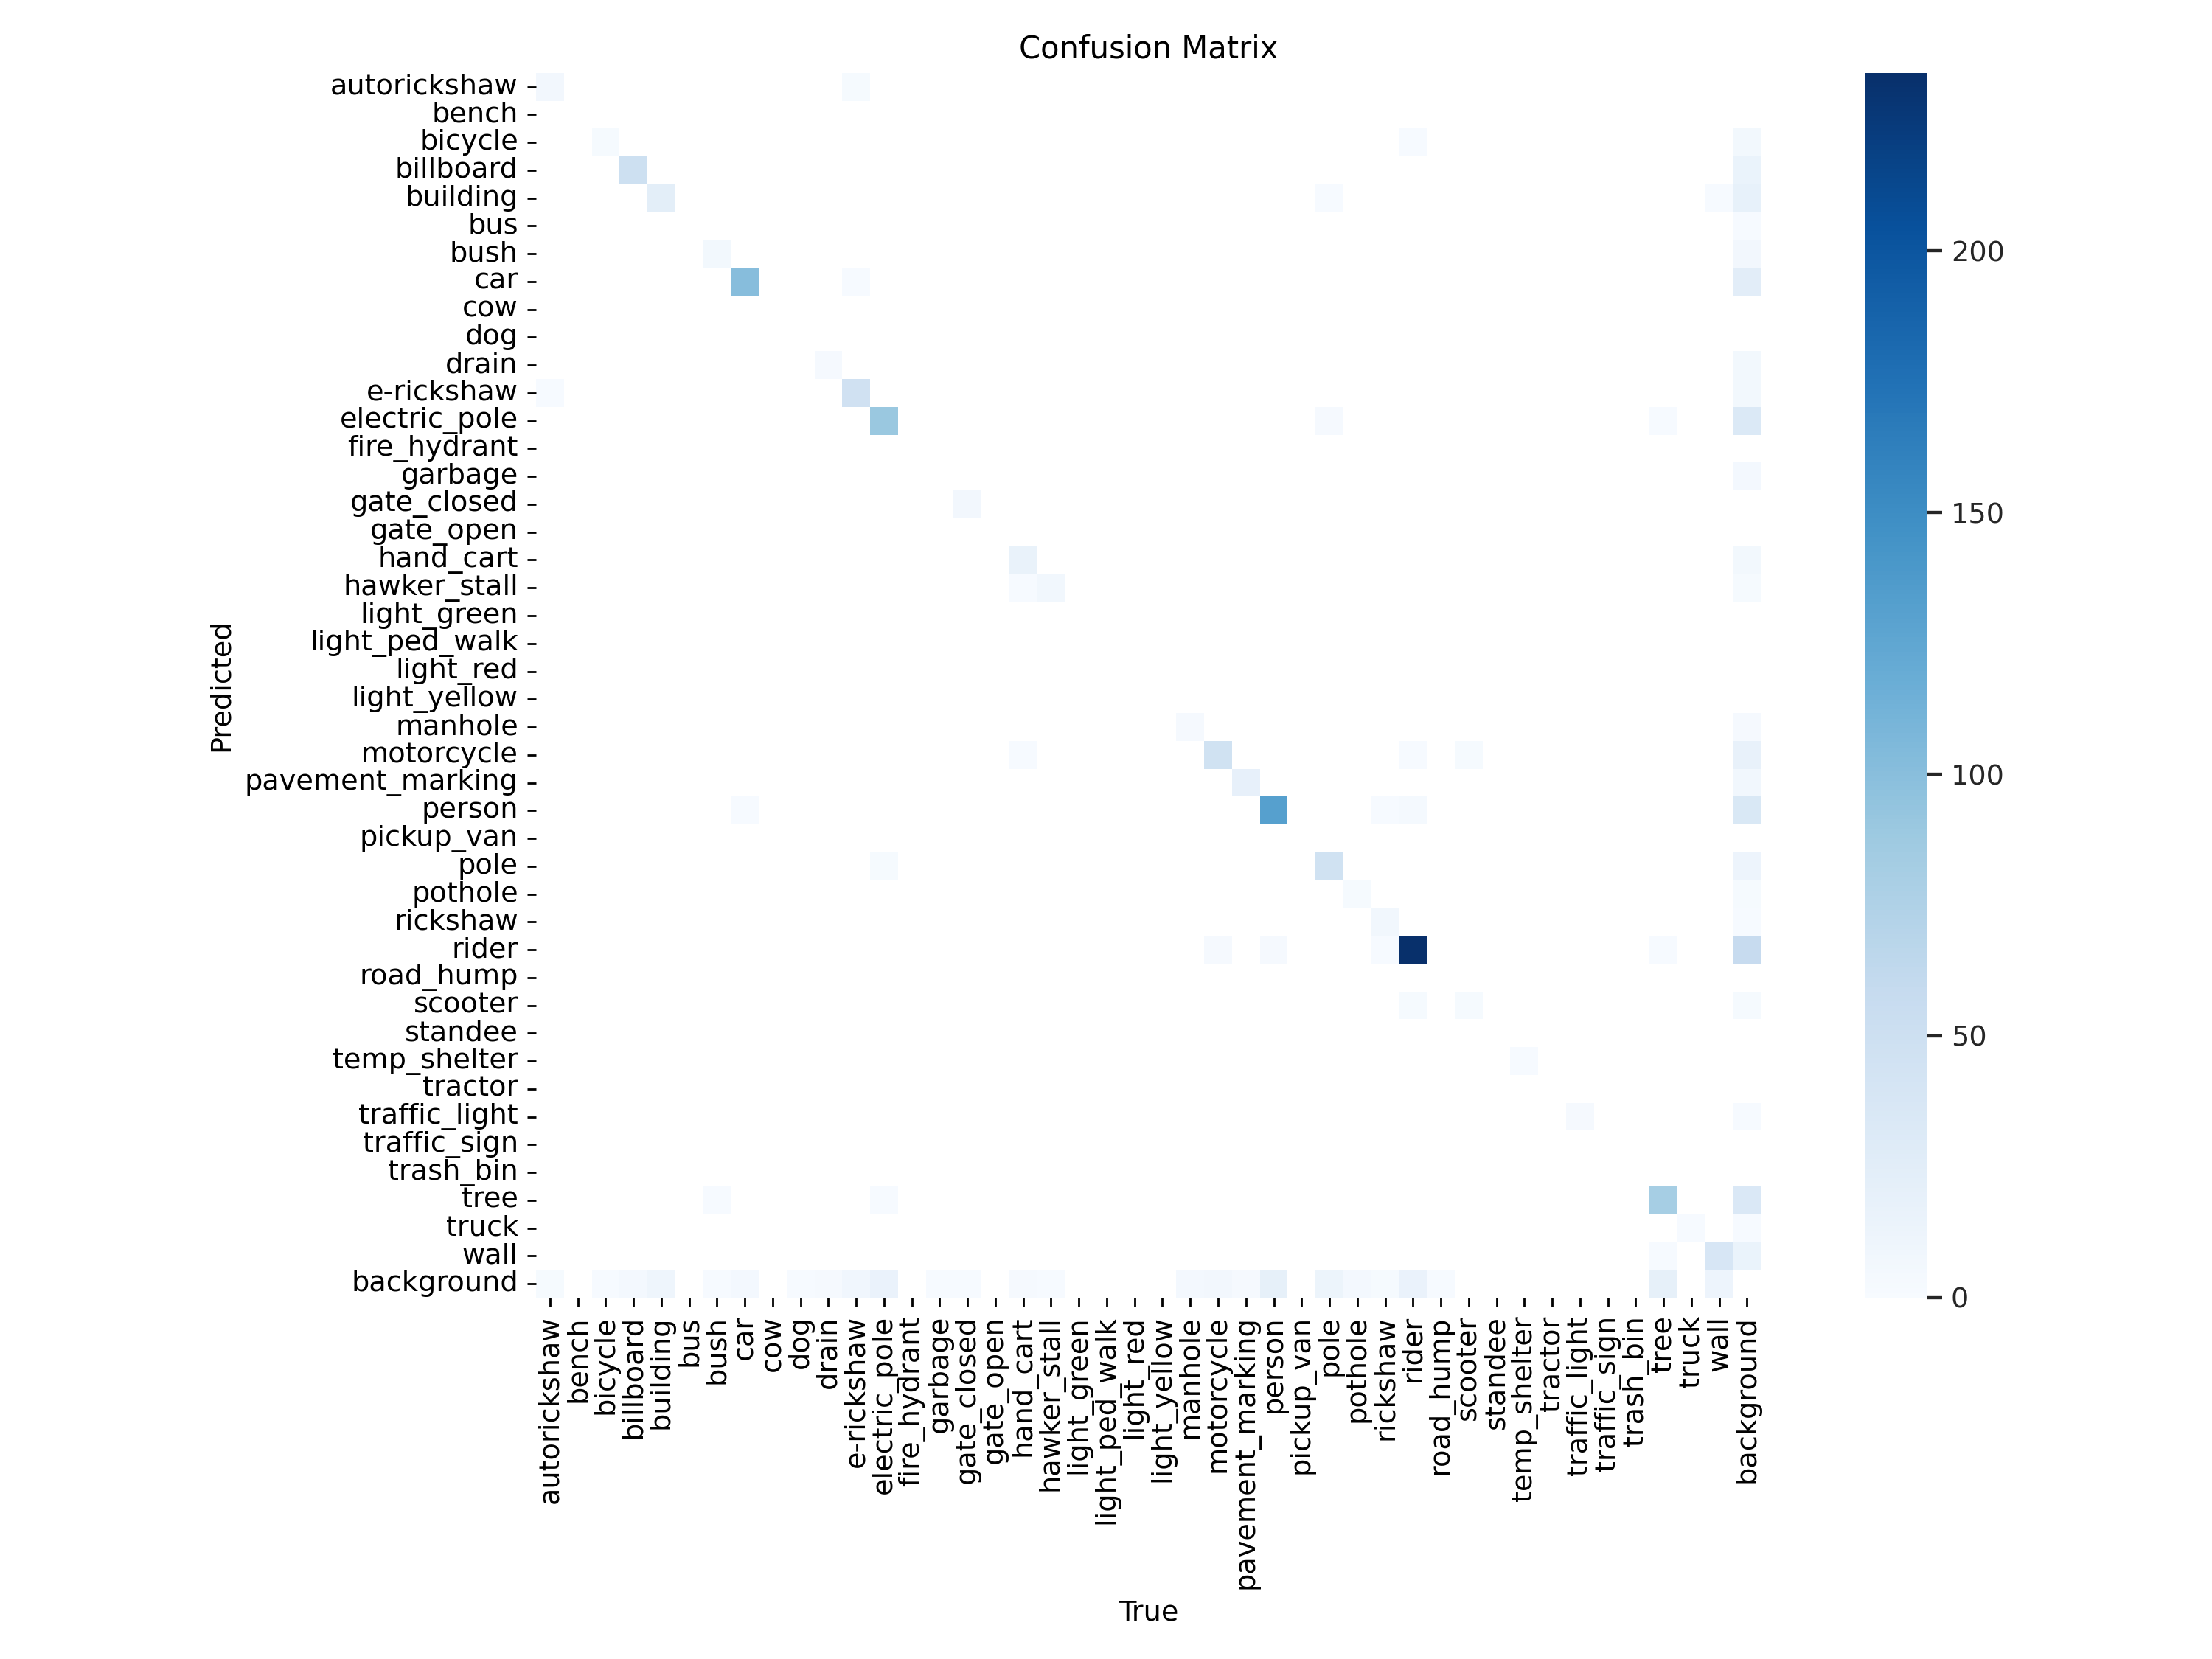

In [15]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train3/confusion_matrix.png', width=600)

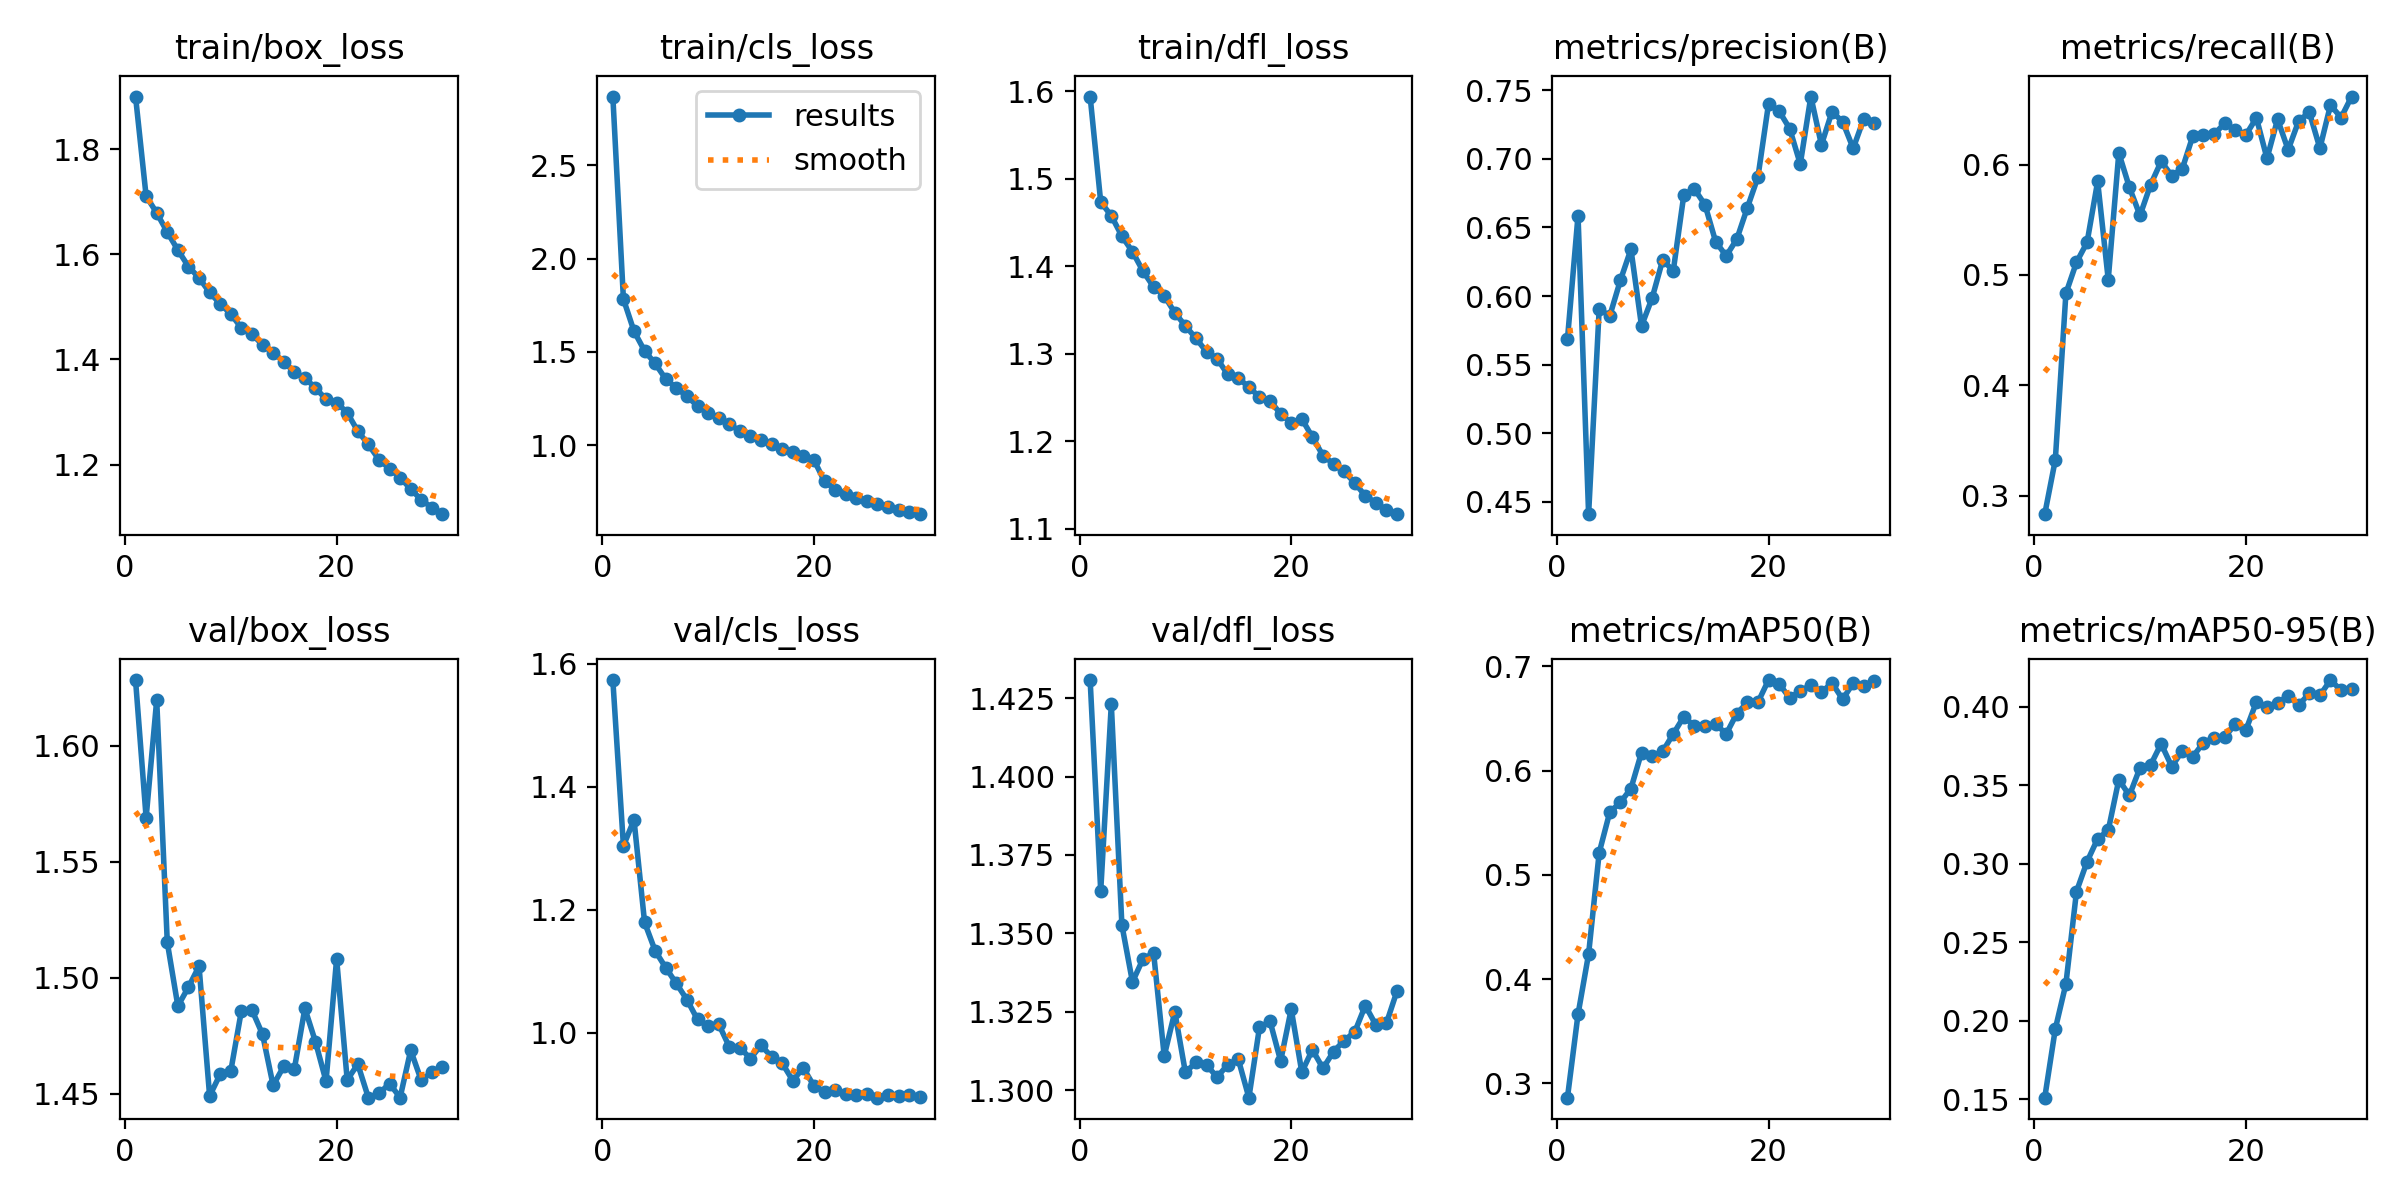

In [16]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train3/results.png', width=600)

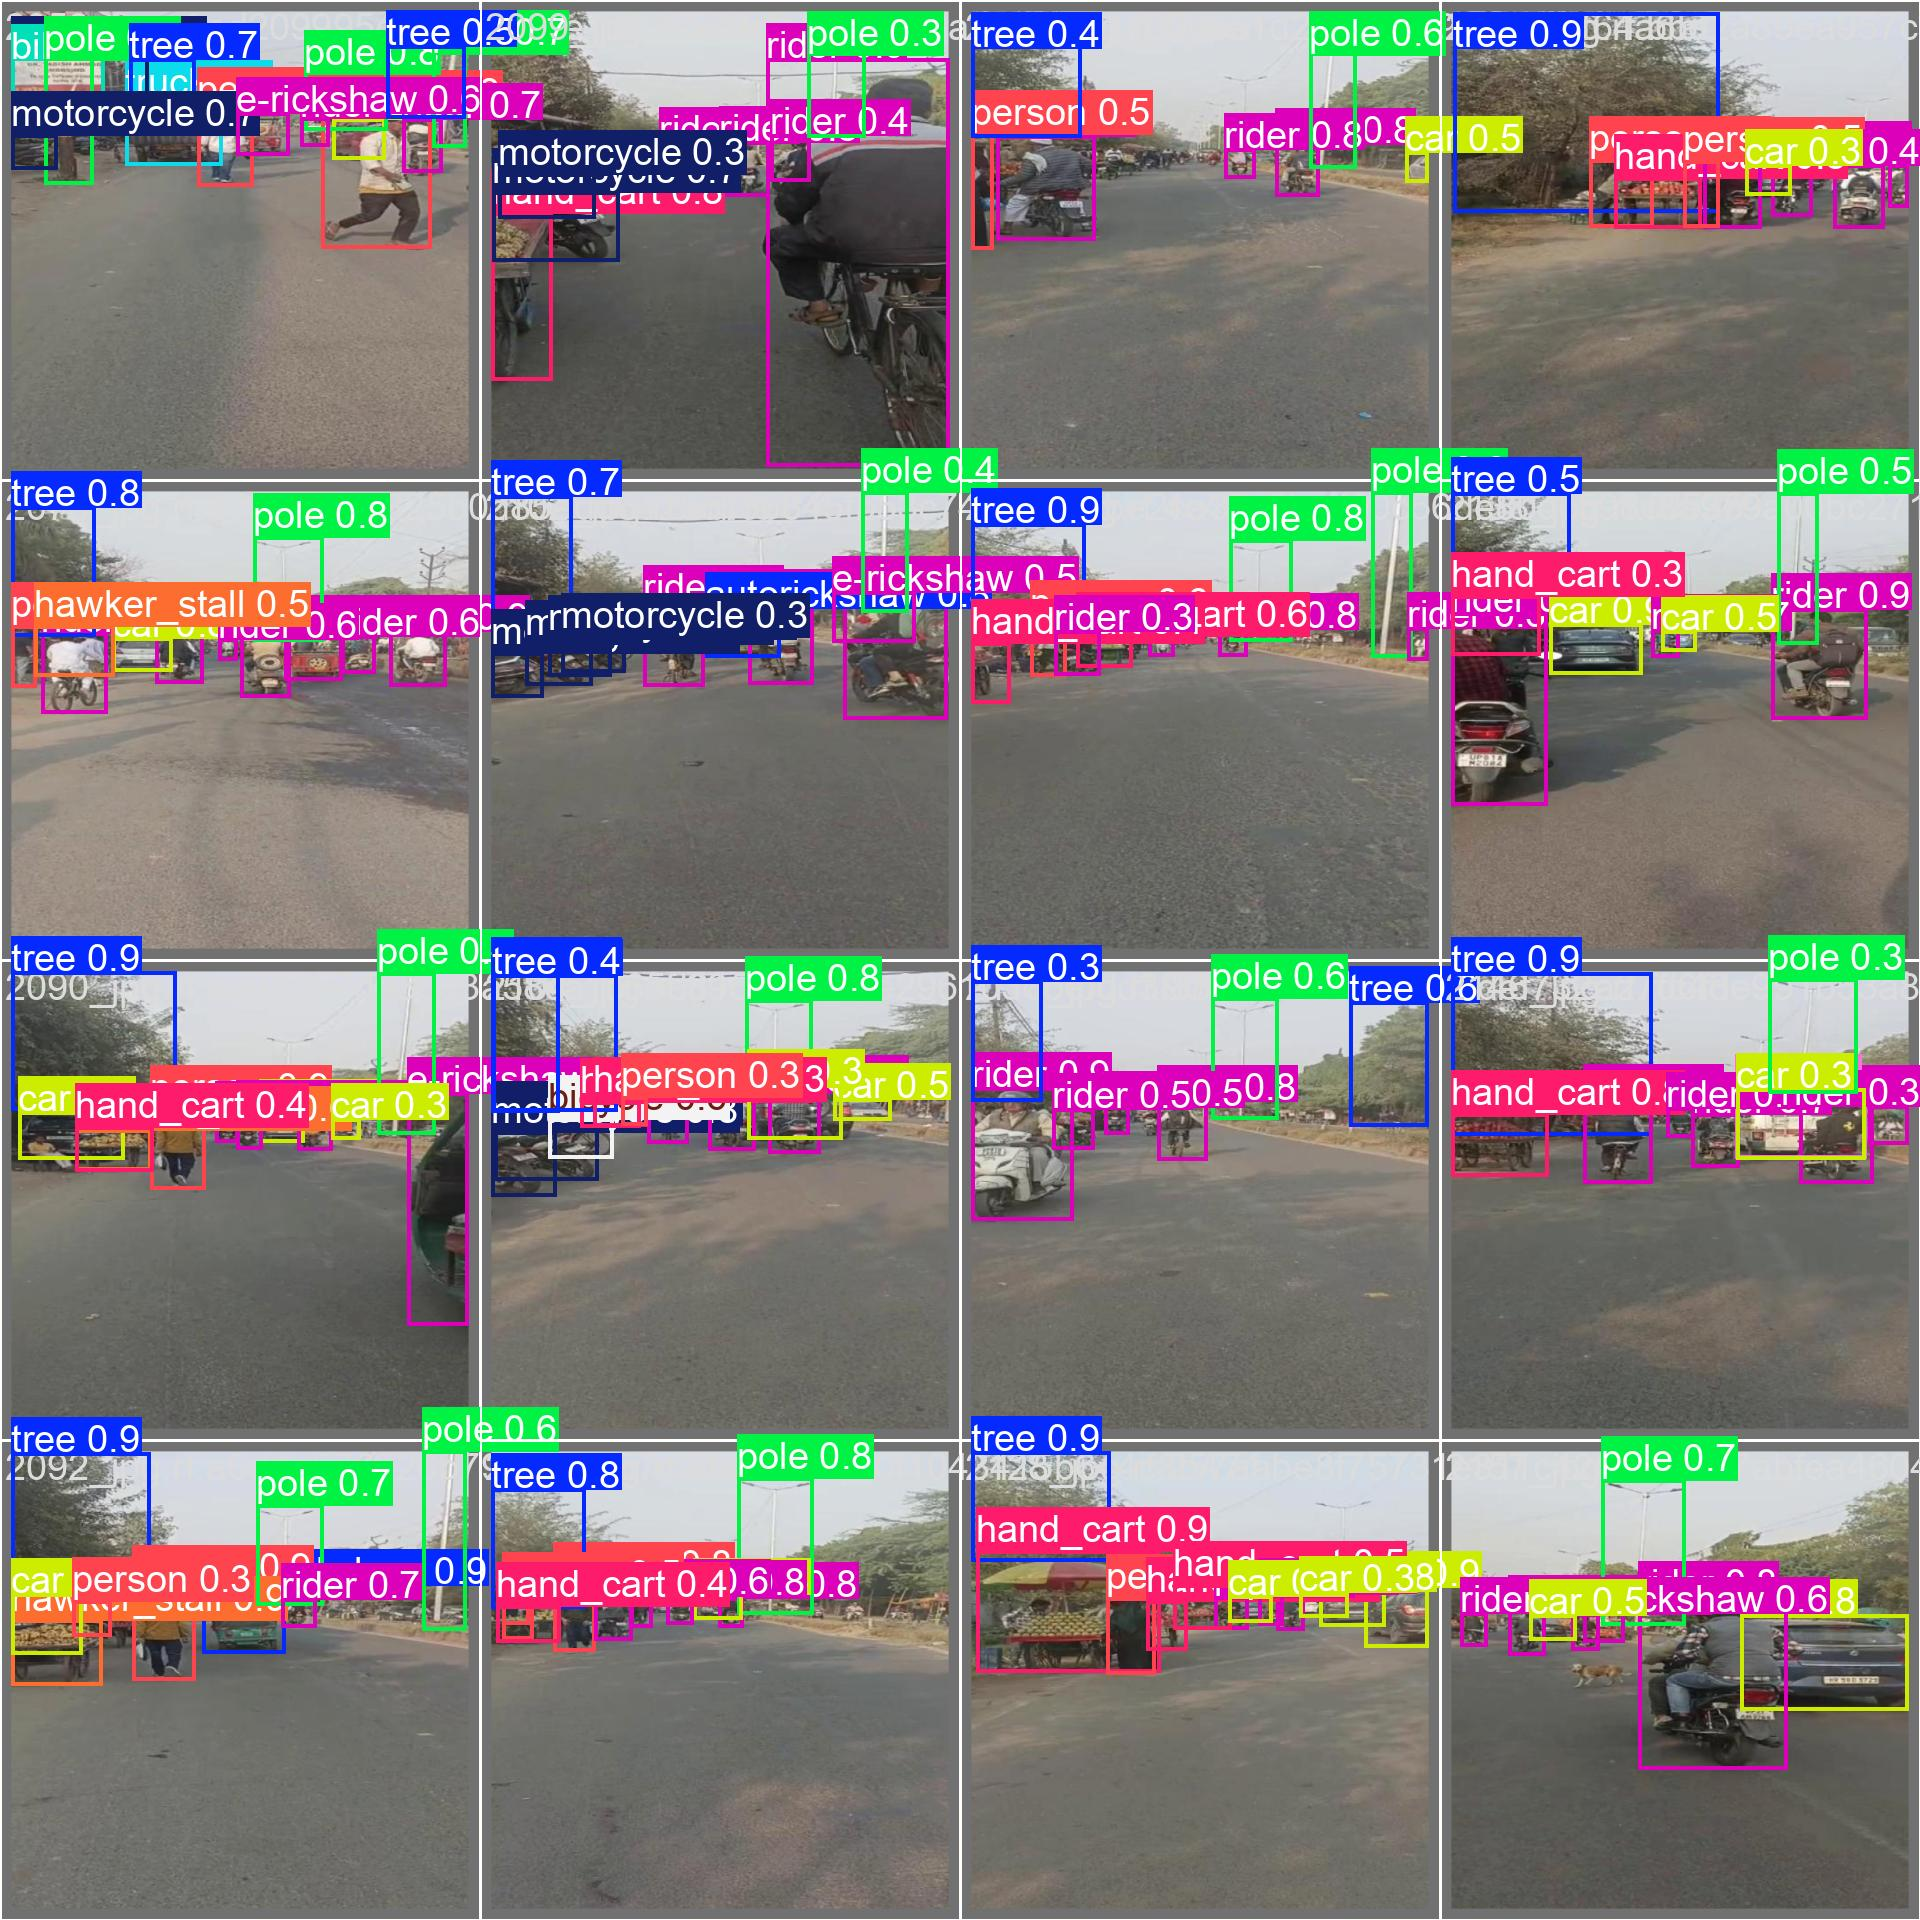

In [17]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train3/val_batch0_pred.jpg', width=600)

In [18]:
!yolo task=detect mode=val model={HOME}/runs/detect/train3/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,429,441 parameters, 0 gradients, 21.4 GFLOPs
val: Scanning /content/combined-dataset-1/valid/labels.cache... 167 images, 0 backgrounds, 0 corrupt: 100% 167/167 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 11/11 [00:05<00:00,  2.17it/s]
                   all        167       1183      0.707      0.654      0.684      0.417
          autorickshaw         10         10      0.832        0.7       0.81      0.501
               bicycle          3          3      0.248      0.667      0.715      0.425
             billboard         38         55      0.857      0.836      0.905      0.619
              building         30         35      0.521      0.629      0.552      0.257
                  bush          8          8      0.551      0.875      0.834      0.588
                   car         81        

In [19]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train3/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,429,441 parameters, 0 gradients, 21.4 GFLOPs

image 1/91 /content/combined-dataset-1/test/images/2058_jpg.rf.42f9d288de6c1ca909c5f30a97a43cdb.jpg: 640x640 1 e-rickshaw, 1 person, 1 pole, 4 riders, 1 tree, 1 truck, 15.6ms
image 2/91 /content/combined-dataset-1/test/images/2073_jpg.rf.4feb42e1f95f76524316e3815f86780b.jpg: 640x640 1 car, 1 e-rickshaw, 1 hawker_stall, 1 person, 1 pole, 3 riders, 1 tree, 15.7ms
image 3/91 /content/combined-dataset-1/test/images/2078_jpg.rf.ffe46e88ddcd28c3d25da0a3b9b085fd.jpg: 640x640 2 cars, 1 motorcycle, 2 persons, 2 poles, 4 riders, 1 tree, 15.6ms
image 4/91 /content/combined-dataset-1/test/images/2079_jpg.rf.52187ee2ef71e3db35937717d377b70a.jpg: 640x640 3 motorcycles, 3 persons, 1 pole, 2 riders, 1 tree, 15.6ms
image 5/91 /content/combined-dataset-1/test/images/2082_jpg.rf.f73f96909441b9ebcb47f5761b59fd13.jpg: 640x640 1 e-rickshaw, 3